# Data exploration notebook for the TPG data

This notebook aims to make a first quick exploration of the TPG riderhip data, and find the effect of public holidays and vacation periods . We will also explore the MeteoSwiss data and add it to the dataset. The notebook exports full and aggregated datasets for later use in ML models.

In [1]:
import numpy as np
import datetime as dt
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# A function to display more columns and rows in the output of a dataframe
def display_df(df, max_rows=-1, max_cols=-1):
    with pl.Config(tbl_cols=max_cols, tbl_width_chars=-1, tbl_rows=max_rows):
        print(df)

## Dataset exploration

Load the TPG dataset. It contains daily data of ridership per line and station for the whole TPG network.
Because it is large, we will use Polars for efficient data manipulation.

In [2]:
# Specify the data types for the CSV file
# We have Date;Line;Line Type;Day Week;Schedule Type;Stop;Long Code Stop;Number of Boarding Passengers;Number of Disembarking Passengers;donnees_definitives;Day Week Index

schema = {"Date": pl.Date,
          "Line": pl.String,
          "Line Type": pl.String,
          "Day Week": pl.String,
          "Schedule Type": pl.String,
          "Stop": pl.String,
          "Long Code Stop": pl.String,
          "Number of Boarding Passengers": pl.Float64,
          "Number of Disembarking Passengers": pl.Float64,
          "donnees_definitives": pl.String,
          "Day Week Index": pl.Int64}

tpg_df = pl.read_csv("tpg_data/montees-par-arret-par-ligne.csv",
            separator=';',
            schema_overrides=schema,)

In [3]:
# Show the first few rows of the DataFrame
print(tpg_df.head())

print(tpg_df.shape)

print(tpg_df.columns)

shape: (5, 11)
┌────────────┬──────┬───────────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ Date       ┆ Line ┆ Line Type ┆ Day Week   ┆ … ┆ Number of  ┆ Number of  ┆ donnees_d ┆ Day Week  │
│ ---        ┆ ---  ┆ ---       ┆ ---        ┆   ┆ Boarding   ┆ Disembarki ┆ efinitive ┆ Index     │
│ date       ┆ str  ┆ str       ┆ str        ┆   ┆ Passengers ┆ ng         ┆ s         ┆ ---       │
│            ┆      ┆           ┆            ┆   ┆ ---        ┆ Passeng…   ┆ ---       ┆ i64       │
│            ┆      ┆           ┆            ┆   ┆ f64        ┆ ---        ┆ str       ┆           │
│            ┆      ┆           ┆            ┆   ┆            ┆ f64        ┆           ┆           │
╞════════════╪══════╪═══════════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ 2025-01-17 ┆ 17   ┆ PRINCIPAL ┆ 5-Vendredi ┆ … ┆ 324.33     ┆ 197.81     ┆ True      ┆ 5         │
│ 2025-01-17 ┆ 17   ┆ PRINCIPAL ┆ 5-Vendredi ┆ … ┆ 167.66     ┆ 254.58     ┆

In [4]:
# For each column, show the number of unique values and the most common value
for column in tpg_df.columns:
    unique_values = tpg_df[column].n_unique()
    most_common_value = tpg_df[column].mode()[0]
    print(f"Column: {column}")
    print(f"Number of unique values: {unique_values}")
    print(f"Most common value: {most_common_value}")
    print("-" * 40)

Column: Date
Number of unique values: 1184
Most common value: 2023-03-24
----------------------------------------
Column: Line
Number of unique values: 112
Most common value: 38
----------------------------------------
Column: Line Type
Number of unique values: 5
Most common value: SECONDAIRE
----------------------------------------
Column: Day Week
Number of unique values: 7
Most common value: 5-Vendredi
----------------------------------------
Column: Schedule Type
Number of unique values: 4
Most common value: NORMAL
----------------------------------------
Column: Stop
Number of unique values: 1026
Most common value: Gare Cornavin
----------------------------------------
Column: Long Code Stop
Number of unique values: 2355
Most common value: METR00
----------------------------------------
Column: Number of Boarding Passengers
Number of unique values: 421528
Most common value: 0.0
----------------------------------------
Column: Number of Disembarking Passengers
Number of unique valu

## Aggregation by date

In [5]:
# Aggregate the data by 'Date' and sum the 'Number of Boarding Passengers'
boarding_passengers_by_date = tpg_df.group_by("Date").agg(pl.col("Number of Boarding Passengers").sum()).sort("Date")

/home/david/miniforge3/envs/py312ml/lib/python3.12/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


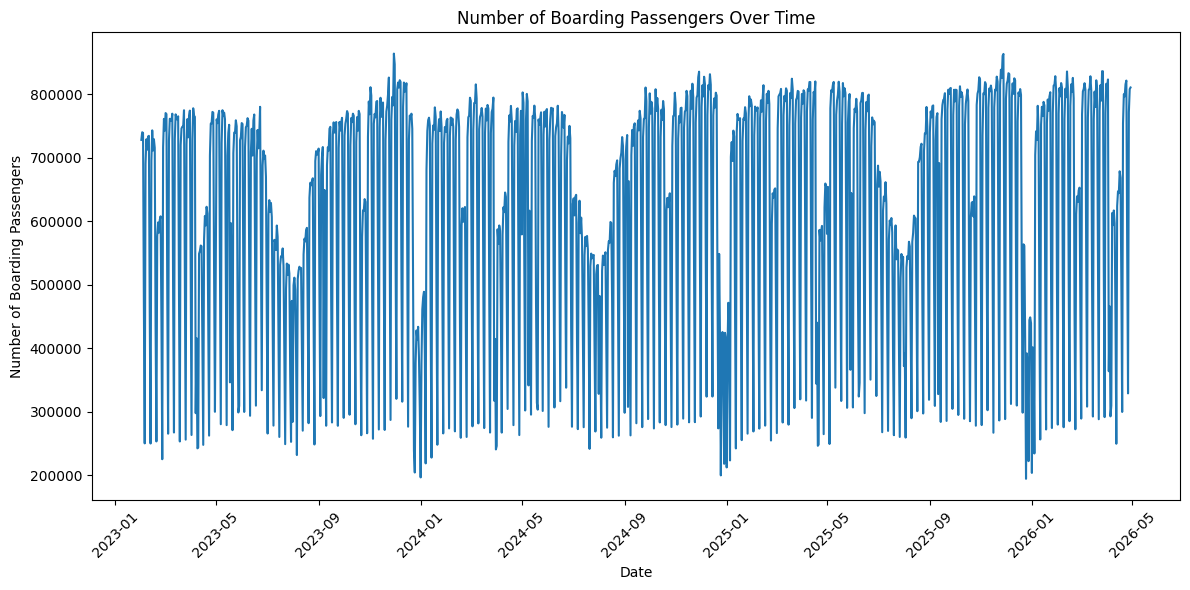

In [6]:
# Plot the number of boarding passengers over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=boarding_passengers_by_date, x="Date", y="Number of Boarding Passengers")
plt.title("Number of Boarding Passengers Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Boarding Passengers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Creating features: vacation and public holiday indicators

To go a bit further, we compile the vacation and public holiday periods into boolean features that indicate whether a given date falls into one of these periods. This will allow us to analyze the impact of vacations and public holidays on ridership.

In [7]:
# Create dataframes with the summer vacation period (two months: July and August) and
# the winter vacation period (two weeks in December and January) for the years 2022 to 2026

## First we define the boundaries of the long vacation periods
autumn_vacation_periods = [("2022-10-22", "2022-10-30"), # Saturday included to Sunday included
                           ("2023-10-21", "2023-10-29"), # Saturday included to Sunday included
                           ("2024-10-19", "2024-10-27"), # Saturday included to Sunday included
                           ("2025-10-18", "2025-10-26")  # Saturday included to Sunday included
                       ]

winter_vacation_periods = [("2022-12-24", "2023-01-08"), # Saturday included to Sunday included
                           ("2023-12-23", "2024-01-07"), # Saturday included to Sunday included
                           ("2024-12-21", "2025-01-05"), # Saturday included to Sunday included
                           ("2025-12-20", "2026-01-04") # Saturday included to Sunday included
                           ]

february_vacation_periods = [("2023-02-18", "2023-02-26"), # Saturday included to Sunday included
                             ("2024-02-19", "2024-02-25"), # Saturday included to Sunday included
                             ("2025-02-22", "2025-03-02"), # Saturday included to Sunday included
                             ("2026-02-21", "2026-03-01") # Saturday included to Friday included
                            ]

easter_vacation_periods = [("2023-04-07", "2023-04-23"), # Friday included to Sunday included
                           ("2024-03-29", "2024-04-14"), # Friday included to Sunday included
                           ("2025-04-18", "2025-05-05"), # Friday included to Sunday included
                           ("2026-04-03", "2026-04-19") # Friday included to Sunday included
                            ]

summer_vacation_periods = [("2023-07-01", "2023-08-20"), # Saturday included to Sunday included
                            ("2024-06-29", "2024-08-18"), # Saturday included to Sunday included
                            ("2025-06-28", "2025-08-17"), # Saturday included to Sunday included
                            ("2026-06-27", "2026-08-16") # Saturday included to Sunday included
                            ]

# Define the Jours Fériés (public holidays) in Geneva for the years 2022 to 2026
public_holidays = ["2022-09-08", # Jeune Genevois
                   "2022-12-25", # Noël
                   "2022-12-31", # Restauration de la Republique / Saint-Sylvestre
                   "2023-01-01", # Nouvel An
                   "2023-04-07", # Vendredi Saint
                   "2023-04-10", # Lundi de Pâques
                   "2023-05-01", # Fête du Travail (seulement écoles)
                   "2023-05-18", # Ascension
                   "2023-05-19", # Vendredi de l'Ascension
                   "2023-05-29", # Lundi de Pentecôte
                   "2023-08-01", # Fête Nationale
                   
                   "2023-09-07", # Jeune Genevois
                   "2023-12-25", # Noël
                   "2023-12-31", # Restauration de la Republique / Saint-Sylvestre
                   "2024-01-01", # Nouvel An
                   "2024-03-29", # Vendredi Saint
                   "2024-04-01", # Lundi de Pâques
                   "2024-05-01", # Fête du Travail (seulement écoles)
                   "2024-05-09", # Ascension
                   "2024-05-10", # Vendredi de l'Ascension
                   "2024-05-20", # Lundi de Pentecôte
                   "2024-08-01", # Fête Nationale
                   
                   "2024-09-05", # Jeune Genevois
                   "2024-12-25", # Noël
                   "2024-12-31", # Restauration de la Republique / Saint-Sylvestre
                   "2025-01-01", # Nouvel An
                   "2025-04-18", # Vendredi Saint
                   "2025-04-21", # Lundi de Pâques
                #    "2025-05-01", # Fête du Travail (seulement écoles)
                   "2025-05-29", # Ascension
                   "2025-05-30", # Vendredi de l'Ascension
                   "2025-06-09", # Lundi de Pentecôte
                   "2025-08-01", # Fête Nationale
                   
                   "2025-09-11", # Jeune Genevois
                   "2025-12-25", # Noël
                   "2025-12-31", # Restauration de la Republique / Saint-Sylvestre
                   "2026-01-01", # Nouvel An
                   "2026-04-03", # Vendredi Saint
                   "2026-04-06", # Lundi de Pâques
                   "2026-05-01", # Fête du Travail (seulement écoles)
                   "2026-05-14", # Ascension
                   "2026-05-15", # Vendredi de l'Ascension
                   "2026-05-25", # Lundi de Pentecôte
                   "2026-08-01", # Fête Nationale
                     ]
                     

# Create a dataframe that contains all the dates in the vacation period for the years 2022 to 2026
list_of_date_ranges_autumn = [pl.DataFrame({"Date": pl.date_range(start=dt.datetime.fromisoformat(period[0]),
                                                                  end=dt.datetime.fromisoformat(period[1]),
                                                                  interval="1d", eager=True)}) for period in autumn_vacation_periods]

list_of_date_ranges_winter = [pl.DataFrame({"Date": pl.date_range(start=dt.datetime.fromisoformat(period[0]),
                                                                  end=dt.datetime.fromisoformat(period[1]),
                                                                  interval="1d", eager=True)}) for period in winter_vacation_periods]

list_of_date_ranges_february = [pl.DataFrame({"Date": pl.date_range(start=dt.datetime.fromisoformat(period[0]),
                                                                  end=dt.datetime.fromisoformat(period[1]),
                                                                  interval="1d", eager=True)}) for period in february_vacation_periods]

list_of_date_ranges_easter = [pl.DataFrame({"Date": pl.date_range(start=dt.datetime.fromisoformat(period[0]),
                                                                  end=dt.datetime.fromisoformat(period[1]),
                                                                  interval="1d", eager=True)}) for period in easter_vacation_periods]

list_of_date_ranges_summer = [pl.DataFrame({"Date": pl.date_range(start=dt.datetime.fromisoformat(period[0]),
                                                                  end=dt.datetime.fromisoformat(period[1]),
                                                                  interval="1d", eager=True)}) for period in summer_vacation_periods]

public_holidays_df = pl.DataFrame({"Date": [dt.date.fromisoformat(isodate) for isodate in public_holidays]})

In [8]:
# Now convert the list of date ranges into a single dataframe with a single column "Date"
autumn_vacation_df = pl.concat(list_of_date_ranges_autumn, how="vertical")
winter_vacation_df = pl.concat(list_of_date_ranges_winter, how="vertical")
february_vacation_df = pl.concat(list_of_date_ranges_february, how="vertical")
easter_vacation_df = pl.concat(list_of_date_ranges_easter, how="vertical")
summer_vacation_df = pl.concat(list_of_date_ranges_summer, how="vertical")

Here we add the vacation date and public holiday dates as boolean features to the main dataframe. This will allow us to analyze the impact of vacations and public holidays on ridership.

In [9]:
tpg_df = tpg_df.with_columns(
    pl.col("Date").is_in(autumn_vacation_df["Date"].implode()).alias("is_autumn_vacation"),
    pl.col("Date").is_in(winter_vacation_df["Date"].implode()).alias("is_winter_vacation"),
    pl.col("Date").is_in(february_vacation_df["Date"].implode()).alias("is_february_vacation"),
    pl.col("Date").is_in(easter_vacation_df["Date"].implode()).alias("is_easter_vacation"),
    pl.col("Date").is_in(summer_vacation_df["Date"].implode()).alias("is_summer_vacation"),
    pl.col("Date").is_in(public_holidays_df["Date"].implode()).alias("is_public_holiday")
)
tpg_df.head()

Date,Line,Line Type,Day Week,Schedule Type,Stop,Long Code Stop,Number of Boarding Passengers,Number of Disembarking Passengers,donnees_definitives,Day Week Index,is_autumn_vacation,is_winter_vacation,is_february_vacation,is_easter_vacation,is_summer_vacation,is_public_holiday
date,str,str,str,str,str,str,f64,f64,str,i64,bool,bool,bool,bool,bool,bool
2025-01-17,"""17""","""PRINCIPAL""","""5-Vendredi""","""NORMAL""","""Grange-Falquet""","""GFAQ01""",324.33,197.81,"""True""",5,false,false,false,false,false,false
2025-01-17,"""17""","""PRINCIPAL""","""5-Vendredi""","""NORMAL""","""Grangettes""","""GRAN00""",167.66,254.58,"""True""",5,false,false,false,false,false,false
2025-01-17,"""17""","""PRINCIPAL""","""5-Vendredi""","""NORMAL""","""Moillesulaz""","""MOIL08""",639.42,821.5,"""True""",5,false,false,false,false,false,false
2025-01-17,"""17""","""PRINCIPAL""","""5-Vendredi""","""NORMAL""","""Moillesulaz - F""","""_MOILF""",121.91,101.8,"""True""",5,false,false,false,false,false,false
2025-01-17,"""17""","""PRINCIPAL""","""5-Vendredi""","""NORMAL""","""Palettes""","""PALE08""",2.25,0.0,"""True""",5,false,false,false,false,false,false


In [10]:
# Aggregate the data by 'Date' and sum the 'Number of Boarding Passengers'
boarding_passengers_by_date = tpg_df.group_by("Date").agg(pl.col("Number of Boarding Passengers").sum(),
                                                          pl.col("is_autumn_vacation").first(),
                                                          pl.col("is_winter_vacation").first(),
                                                          pl.col("is_february_vacation").first(),
                                                          pl.col("is_easter_vacation").first(),
                                                          pl.col("is_summer_vacation").first(),
                                                          pl.col("is_public_holiday").first()
                                                          ).sort("Date")

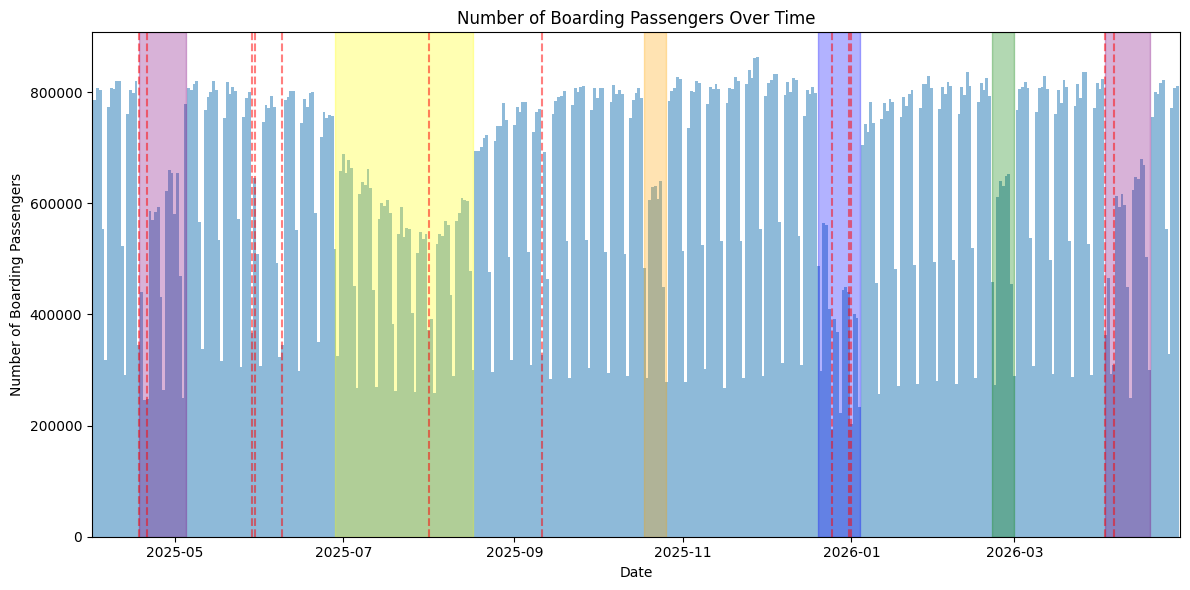

In [11]:
# Plot the number of boarding passengers over time

fig, ax = plt.subplots(figsize=(12, 6))

interval = dt.timedelta(days=1)
ax.bar(boarding_passengers_by_date["Date"],
       boarding_passengers_by_date["Number of Boarding Passengers"],
       width=interval, alpha=0.5, label="Number of Boarding Passengers")

ax.set_title("Number of Boarding Passengers Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Boarding Passengers")

# ax.set_xlim(boarding_passengers_by_date["Date"].min(), boarding_passengers_by_date["Date"].max())

# ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Add yellow areas for the summer vacation periods
for ii_period, period in enumerate(summer_vacation_periods):
    ax.axvspan(dt.datetime.fromisoformat(period[0]),
               dt.datetime.fromisoformat(period[1]), color='yellow', alpha=0.3)

## Add blue areas for the winter vacation periods
for ii_period, period in enumerate(winter_vacation_periods):
    ax.axvspan(dt.datetime.fromisoformat(period[0]),
               dt.datetime.fromisoformat(period[1]), color='blue', alpha=0.3)

## Add orange areas for the autumn vacation periods
for ii_period, period in enumerate(autumn_vacation_periods):
    ax.axvspan(dt.datetime.fromisoformat(period[0]),
               dt.datetime.fromisoformat(period[1]), color='orange', alpha=0.3)
    
## Add purple areas for the easter vacation periods
for ii_period, period in enumerate(easter_vacation_periods):
    ax.axvspan(dt.datetime.fromisoformat(period[0]),
               dt.datetime.fromisoformat(period[1]), color='purple', alpha=0.3)
    
## Add green areas for the february vacation periods
for ii_period, period in enumerate(february_vacation_periods):
    ax.axvspan(dt.datetime.fromisoformat(period[0]),
               dt.datetime.fromisoformat(period[1]), color='green', alpha=0.3)

## Add single red vertical lines for the public holidays
for ii_holiday, holiday in enumerate(public_holidays):
    ax.axvline(dt.datetime.fromisoformat(holiday), color='red', alpha=0.5, linestyle='--')

## Zoom in on the x-axis
ax.set_xlim(dt.datetime(2025, 4, 1), dt.datetime(2026, 4, 30))

fig.tight_layout()
plt.show()

For fun we also add the Servete Hockey club matches a domiciles as a boolean feature, to see if there is an effect on ridership on match days.
Data from https://www.sihf.ch/fr/game-center/national-league

In [12]:
# Create a small function to process the SIHF data files and extract the home matches of Servette HC,
# and return them as a dataframe with a single column "Date"
def get_servette_hc_home_matches_dataframe(file_path):
    # Read the CSV file
    df = pl.read_csv(file_path, separator=";")
    
    # Convert the "Datum" column to datetime format and filter for home matches of Servette HC
    df = df.filter(pl.col("Home") == "Genève-Servette HC").with_columns(
            pl.col("Datum").str.to_date("%d.%m.%Y").alias("Date")).select("Date").sort("Date")
    
    return df

matches_2022_2023 = get_servette_hc_home_matches_dataframe("other_data/servette_hc/Spiele__2022_2023.csv")
matches_2023_2024 = get_servette_hc_home_matches_dataframe("other_data/servette_hc/Spiele__2023_2024.csv")
matches_2024_2025 = get_servette_hc_home_matches_dataframe("other_data/servette_hc/Spiele__2024_2025.csv")
matches_2025_2026 = get_servette_hc_home_matches_dataframe("other_data/servette_hc/Spiele__2025_2026.csv")

# Gather all the matches in a single dataframe and sort by date
servette_hc_home_matches_df = pl.concat([matches_2022_2023,
                                         matches_2023_2024,
                                         matches_2024_2025,
                                         matches_2025_2026],
                                        how="vertical").sort("Date")

## If we want to check the full list of matches
# with pl.Config(tbl_cols=-1, tbl_width_chars=-1, tbl_rows=-1):
#     print(matches_2022_2023)

In [13]:
# Add the Servette HC home matches as a boolean feature to the tpg_df dataframe
tpg_df = tpg_df.with_columns(
    pl.col("Date").is_in(servette_hc_home_matches_df["Date"].implode()).alias("is_servette_hc_home_match")
)

## Explore the MeteoSuisse data

Data Source: MeteoSwiss

Source for API data download: https://github.com/MeteoSwiss/opendata/blob/main/notebooks/MonthlyMeanGlobalRadiation_HAI.ipynb

In [14]:
# Define file URLs: we want Geneva Cointrin data (GVE)
# Daily data -> d in suffix
# Monthly data -> m in suffix
historical_url = "https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/gve/ogd-smn_gve_d_historical.csv"
recent_url = "https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/gve/ogd-smn_gve_d_recent.csv"

In [15]:
def download_csv(url):
    """
    Downloads a CSV file from a given URL and returns a Pandas DataFrame.
    """
    try:
        # in production, please check if a local copy of the files already exists. If so, please
        # send the ETag of the local resource (that you got in the response when initially
        # requesting the resource) in an If-None-Match header. The server will only send the file,
        # if the remote version is newer than your local file. This avoids unnecessary traffic.
        # (also check here: https://data.geo.admin.ch/api/stac/static/spec/v1/apitransactional.html#tag/Data/operation/getAssetObject)
        # For our short example, we don't need to do 4all this.
        df = pl.read_csv(url, separator=';')
        return df
    # too broad exception, I know. Please use better error handling in production ;-)
    except Exception as e:
        print(f"Error downloading {url}: {e}")
        return None
    
recent_data_df_down = download_csv(recent_url)
historical_data_df_down = download_csv(historical_url)

In [16]:
# Make a copy of the downloaded dataframes to work with
recent_data_df = recent_data_df_down.clone()
historical_data_df = historical_data_df_down.clone()

display(recent_data_df.tail())

# That's a lot of colums, let's try to make sense of the features we want to keep

meteo_parameters_df = pl.read_csv('./meteo_data_gve_cointrin/ogd-smn_meta_parameters.csv', separator=';', encoding='windows-1252')

# Keep only the columns with the description in fr or en
meteo_parameters_df = meteo_parameters_df.select(['parameter_shortname',
                            'parameter_description_fr', 'parameter_description_en',
                            'parameter_group_fr', 'parameter_group_en',
                            'parameter_granularity', 'parameter_datatype', 'parameter_unit'])

# We will only keep daily granularity, and precipitation and temperature groups
meteo_parameters_df = meteo_parameters_df.filter(pl.col("parameter_granularity") == "D",
                                                 pl.col("parameter_group_en").is_in(["Precipitation", "Temperature"])
                                                 )
with pl.Config(tbl_cols=-1, tbl_width_chars=-1, tbl_rows=-1):
    display(meteo_parameters_df)

# Select which parameters we want to keep in the meteo data, and rename them with more explicit names
# The shortname that we will keep in the meteo data are:
# rre150d0: Précipitations; somme journalière 6 UTC - 6 UTC du jour suivant / Precipitation; daily total 6 UTC - 6 UTC following day
# tre200d0: Température de l'air à 2 m du sol; moyenne journalière / Air temperature 2 m above ground; daily mean
# tre200dn: Température de l'air à 2 m du sol; minimum journalier / Air temperature 2 m above ground; daily minimum
# tre200dx: Température de l'air à 2 m du sol; maximum journalier / Air temperature 2 m above ground; daily maximum

parameters_to_keep_list = ["reference_timestamp", "rre150d0", "tre200d0", "tre200dn", "tre200dx"]
explicit_name_of_parameters_to_keep_list = ["reference_timestamp", "precipitation_in_mm", "mean_air_temperature_2m_in_C",
                                       "minimum_air_temperature_2m_in_C", "maximum_air_temperature_2m_in_C"]

recent_data_df = recent_data_df.select(pl.col(parameters_to_keep_list))
historical_data_df = historical_data_df.select(pl.col(parameters_to_keep_list))

# Convert the reference_timestamp column to datetime format and rename it to "Date"
recent_data_df = recent_data_df.with_columns(pl.col("reference_timestamp").str.to_datetime("%d.%m.%Y %H:%M").dt.date().alias("Date"))
historical_data_df = historical_data_df.with_columns(pl.col("reference_timestamp").str.to_datetime("%d.%m.%Y %H:%M").dt.date().alias("Date"))

# Rename the columns with more explicit names
recent_data_df = recent_data_df.rename(dict(zip(parameters_to_keep_list, explicit_name_of_parameters_to_keep_list)))
historical_data_df = historical_data_df.rename(dict(zip(parameters_to_keep_list, explicit_name_of_parameters_to_keep_list)))


# Remove the original reference_timestamp column
recent_data_df = recent_data_df.drop("reference_timestamp")
historical_data_df = historical_data_df.drop("reference_timestamp")

# Concatenate the recent and historical dataframes and keep only dates between the min and max date of the tpg_df dataframe
min_date = tpg_df.select(pl.col("Date").min()).item()
max_date = tpg_df.select(pl.col("Date").max()).item()

recent_data_df = recent_data_df.filter(pl.col("Date").is_between(min_date, max_date))
historical_data_df = historical_data_df.filter(pl.col("Date").is_between(min_date, max_date))

# Historical has str instead of float, we need to convert it to float
historical_data_df = historical_data_df.with_columns(
    pl.col("precipitation_in_mm").cast(pl.Float64),
    pl.col("mean_air_temperature_2m_in_C").cast(pl.Float64),
    pl.col("minimum_air_temperature_2m_in_C").cast(pl.Float64),
    pl.col("maximum_air_temperature_2m_in_C").cast(pl.Float64)
)

meteo_data_df = pl.concat([recent_data_df, historical_data_df], how="vertical").sort("Date")

station_abbr,reference_timestamp,tre200d0,tre200dx,tre200dn,tre005d0,tre005dx,tre005dn,ure200d0,pva200d0,prestad0,pp0qffd0,ppz850d0,ppz700d0,pp0qnhd0,fkl010d0,fkl010d1,fu3010d0,fu3010d1,fkl010d3,fu3010d3,wcc006d0,rre150d0,rka150d0,htoautd0,gre000d0,oli000d0,olo000d0,osr000d0,ods000d0,sre000d0,sremaxdv,erefaod0,xcd000d0,dkl010d0,xno000d0,xno012d0,rreetsd0,tso005d0,tso010d0,tso020d0
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,i64,i64,i64,str,str,i64,i64,i64,f64,i64,i64,f64,f64,f64,str,str,str
"""GVE""","""02.05.2026 00:00""",17.6,24.8,9.8,19.0,30.4,6.1,54.1,10.4,972.2,1020.0,null,null,1021.1,2.7,9.1,9.7,32.8,8.8,31.7,null,0.0,0.0,0,297,330,null,null,97,681,85,4.9,0,227,0.0,0.0,-4.1,null,null,null
"""GVE""","""03.05.2026 00:00""",15.0,19.9,11.0,15.0,23.8,9.4,57.7,9.7,968.0,1016.1,null,null,1016.7,2.8,11.7,10.1,42.1,11.2,40.3,null,0.0,0.0,0,131,348,null,null,109,76,9,3.1,0,227,0.0,0.0,-1.0,null,null,null
"""GVE""","""04.05.2026 00:00""",12.2,14.9,10.6,12.0,17.2,9.5,87.0,12.3,966.4,1014.9,null,null,1015.1,1.4,7.8,5.0,28.1,7.4,26.6,null,17.7,7.8,0,66,353,null,null,66,0,0,1.3,0,270,0.0,0.0,7.6,null,null,null
"""GVE""","""05.05.2026 00:00""",12.7,17.8,10.9,13.1,21.8,10.1,86.9,12.6,962.4,1010.6,null,null,1010.9,2.0,9.9,7.2,35.6,9.7,34.9,null,11.5,20.2,0,129,356,null,null,108,57,7,2.2,0,240,0.0,0.0,19.9,null,null,null
"""GVE""","""06.05.2026 00:00""",10.9,14.2,7.9,11.0,18.4,6.6,84.7,10.9,961.9,1010.4,null,null,1010.4,2.4,9.9,8.6,35.6,9.7,34.9,null,10.1,11.3,0,114,338,null,null,105,21,3,1.8,0,229,9.1,1.1,11.0,null,null,null


parameter_shortname,parameter_description_fr,parameter_description_en,parameter_group_fr,parameter_group_en,parameter_granularity,parameter_datatype,parameter_unit
str,str,str,str,str,str,str,str
"""rka150d0""","""Précipitations; somme du jour …","""Precipitation; daily total 0 U…","""Précipitations""","""Precipitation""","""D""","""Float""","""mm"""
"""rre150d0""","""Précipitations; somme journali…","""Precipitation; daily total 6 U…","""Précipitations""","""Precipitation""","""D""","""Float""","""mm"""
"""rreetsd0""","""Apport d'eau (bilan hydrique, …","""Hydrologic registration (hydro…","""Précipitations""","""Precipitation""","""D""","""Float""","""mm"""
"""tre005d0""","""Température de l'air à 5 cm de…","""Air temperature at 5 cm above …","""Température""","""Temperature""","""D""","""Float""","""°C"""
"""tre005dn""","""Température de l'air à 5 cm de…","""Air temperature at 5 cm above …","""Température""","""Temperature""","""D""","""Float""","""°C"""
"""tre005dx""","""Température de l'air à 5 cm de…","""Air temperature at 5 cm above …","""Température""","""Temperature""","""D""","""Float""","""°C"""
"""tre200d0""","""Température de l'air à 2 m du …","""Air temperature 2 m above grou…","""Température""","""Temperature""","""D""","""Float""","""°C"""
"""tre200dn""","""Température de l'air à 2 m du …","""Air temperature 2 m above grou…","""Température""","""Temperature""","""D""","""Float""","""°C"""
"""tre200dx""","""Température de l'air à 2 m du …","""Air temperature 2 m above grou…","""Température""","""Temperature""","""D""","""Float""","""°C"""


shape: (9, 6)
┌────────────┬──────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────┐
│ statistic  ┆ precipitation_in ┆ mean_air_temper ┆ minimum_air_tem ┆ maximum_air_tem ┆ Date       │
│ ---        ┆ _mm              ┆ ature_2m_in_C   ┆ perature_2m_in_ ┆ perature_2m_in_ ┆ ---        │
│ str        ┆ ---              ┆ ---             ┆ …               ┆ …               ┆ str        │
│            ┆ f64              ┆ f64             ┆ ---             ┆ ---             ┆            │
│            ┆                  ┆                 ┆ f64             ┆ f64             ┆            │
╞════════════╪══════════════════╪═════════════════╪═════════════════╪═════════════════╪════════════╡
│ count      ┆ 1184.0           ┆ 1184.0          ┆ 1184.0          ┆ 1184.0          ┆ 1184       │
│ null_count ┆ 0.0              ┆ 0.0             ┆ 0.0             ┆ 0.0             ┆ 0          │
│ mean       ┆ 2.596368         ┆ 11.937584       ┆ 7.02897         ┆ 16.9314

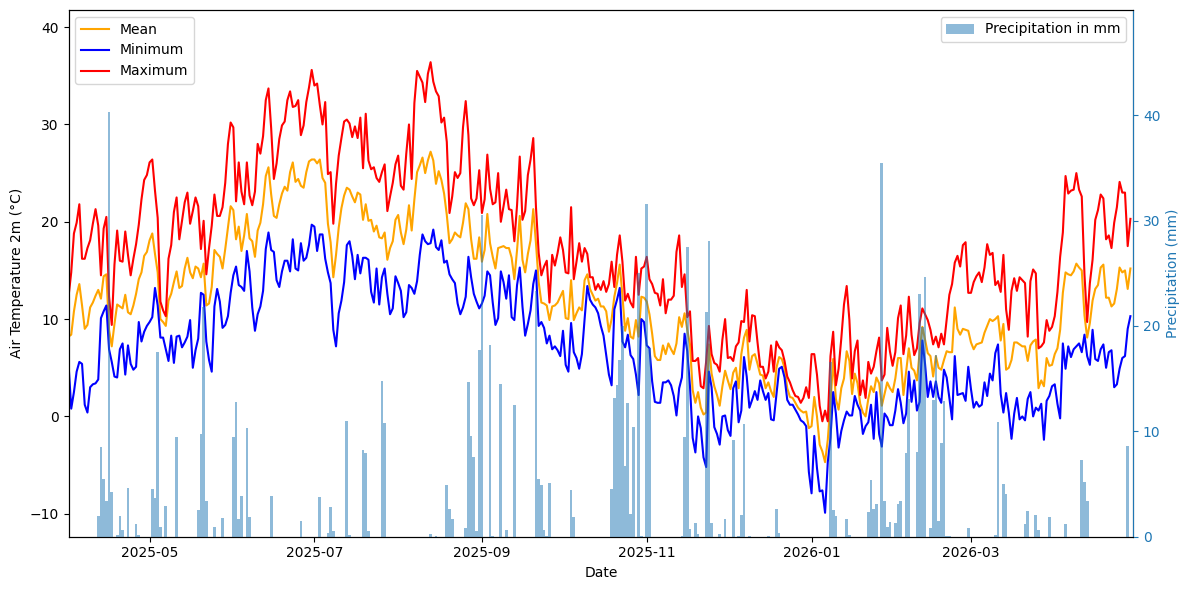

In [17]:
# Show some statistics about the meteo data
print(meteo_data_df.describe())

# Plot the meteo data over time
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# First plot: the temperatures over time
ax.plot(meteo_data_df["Date"], meteo_data_df["mean_air_temperature_2m_in_C"], label="Mean", color="orange")
ax.plot(meteo_data_df["Date"], meteo_data_df["minimum_air_temperature_2m_in_C"], label="Minimum", color="blue")
ax.plot(meteo_data_df["Date"], meteo_data_df["maximum_air_temperature_2m_in_C"], label="Maximum", color="red")

ax.set_xlabel("Date")
ax.set_ylabel("Air Temperature 2m (°C)")
ax.legend(loc="upper left")

# Second plot (on second axis): the precipitation over time
ax2 = ax.twinx()
ax2.bar(meteo_data_df["Date"], meteo_data_df["precipitation_in_mm"],
        width=dt.timedelta(days=1), alpha=0.5, label="Precipitation in mm", color="C0")
ax2.set_ylabel("Precipitation (mm)", color="C0")
ax2.legend(loc="upper right")
# Make the secondary axis the same color as the bars
ax2.spines['right'].set_color("C0")
ax2.tick_params(axis='y', colors="C0")

# Zoom in on the x-axis
ax.set_xlim(dt.datetime(2025, 4, 1), dt.datetime(2026, 4, 30))

fig.tight_layout()

## Concatenate the TPG data with the MeteoSwiss data and export the combined dataset for later use in ML models.

In [18]:
tpg_df.head()

Date,Line,Line Type,Day Week,Schedule Type,Stop,Long Code Stop,Number of Boarding Passengers,Number of Disembarking Passengers,donnees_definitives,Day Week Index,is_autumn_vacation,is_winter_vacation,is_february_vacation,is_easter_vacation,is_summer_vacation,is_public_holiday,is_servette_hc_home_match
date,str,str,str,str,str,str,f64,f64,str,i64,bool,bool,bool,bool,bool,bool,bool
2025-01-17,"""17""","""PRINCIPAL""","""5-Vendredi""","""NORMAL""","""Grange-Falquet""","""GFAQ01""",324.33,197.81,"""True""",5,false,false,false,false,false,false,true
2025-01-17,"""17""","""PRINCIPAL""","""5-Vendredi""","""NORMAL""","""Grangettes""","""GRAN00""",167.66,254.58,"""True""",5,false,false,false,false,false,false,true
2025-01-17,"""17""","""PRINCIPAL""","""5-Vendredi""","""NORMAL""","""Moillesulaz""","""MOIL08""",639.42,821.5,"""True""",5,false,false,false,false,false,false,true
2025-01-17,"""17""","""PRINCIPAL""","""5-Vendredi""","""NORMAL""","""Moillesulaz - F""","""_MOILF""",121.91,101.8,"""True""",5,false,false,false,false,false,false,true
2025-01-17,"""17""","""PRINCIPAL""","""5-Vendredi""","""NORMAL""","""Palettes""","""PALE08""",2.25,0.0,"""True""",5,false,false,false,false,false,false,true


In [21]:
tpg_and_meteo_data_df = pl.concat([tpg_df, meteo_data_df], how="align")

In [22]:
# Show a specific date of meteo data and tpg data to check if the concatenation worked well
date = dt.date(2024, 4, 15)

print("Meteo data for date", date)
display_df(meteo_data_df.filter(pl.col("Date") == date))

print("TPG data for date", date)
display_df(tpg_df.filter(pl.col("Date") == date), max_rows=10)

display_df(tpg_and_meteo_data_df.filter(pl.col("Date") == date), max_rows=10)

Meteo data for date 2024-04-15
shape: (1, 5)
┌─────────────────────┬──────────────────────────────┬─────────────────────────────────┬─────────────────────────────────┬────────────┐
│ precipitation_in_mm ┆ mean_air_temperature_2m_in_C ┆ minimum_air_temperature_2m_in_… ┆ maximum_air_temperature_2m_in_… ┆ Date       │
│ ---                 ┆ ---                          ┆ ---                             ┆ ---                             ┆ ---        │
│ f64                 ┆ f64                          ┆ f64                             ┆ f64                             ┆ date       │
╞═════════════════════╪══════════════════════════════╪═════════════════════════════════╪═════════════════════════════════╪════════════╡
│ 0.8                 ┆ 17.8                         ┆ 11.5                            ┆ 21.5                            ┆ 2024-04-15 │
└─────────────────────┴──────────────────────────────┴─────────────────────────────────┴─────────────────────────────────┴────────────┘
TPG

In [23]:
# Export the dataset for later use in ML models
# First as CSV for interoperability
tpg_and_meteo_data_df.write_csv("tpg_and_meteo_data.csv", separator=';')

# And as a parquet file for better performance when loading the data later in Python (but less interoperable with other software)
tpg_and_meteo_data_df.write_parquet("tpg_and_meteo_data.parquet")

In [24]:
# Make some additional dataframes where we aggregate some features, for easier use to train ML models later on

# Aggregate by "Line"
line_aggregated_tpg_and_meteo_df = tpg_and_meteo_data_df.group_by("Line", "Date").agg(pl.col("Number of Boarding Passengers").sum().alias("total_number_of_boarding_passengers"),
                                                   pl.col("Number of Disembarking Passengers").sum().alias("total_number_of_disembarking_passengers"),
                                                   pl.col("Line Type").first().alias("line_type"),
                                                   pl.col("Day Week").first().alias("day_week"),
                                                   pl.col("Schedule Type").first().alias("schedule_type"),
                                           pl.col("precipitation_in_mm").mean(),
                                           pl.col("mean_air_temperature_2m_in_C").mean(),
                                           pl.col("minimum_air_temperature_2m_in_C").mean(),
                                           pl.col("maximum_air_temperature_2m_in_C").mean(),
                                           pl.col("is_autumn_vacation").first(),
                                           pl.col("is_winter_vacation").first(),
                                           pl.col("is_february_vacation").first(),
                                           pl.col("is_easter_vacation").first(),
                                           pl.col("is_summer_vacation").first(),
                                           pl.col("is_public_holiday").first(),
                                           pl.col("is_servette_hc_home_match").first()
                                           ).sort("Date", "Line")

In [25]:
# Export the combined dataframe to a CSV file for later use in ML models
line_aggregated_tpg_and_meteo_df.write_csv("line_aggregated_tpg_and_meteo.csv", separator=';')

# And 
line_aggregated_tpg_and_meteo_df.write_parquet("line_aggregated_tpg_and_meteo.parquet")